# Notebook 7: Loss Functions and Training in AlphaFold2

**Objective:** Understand how AlphaFold2 is trained -- the loss functions that teach the network to predict accurate 3D structures, with focus on the novel FAPE loss.

---

AlphaFold2 is an extraordinarily complex system with multiple output heads, each supervised by its own loss term. The total training loss orchestrates learning across structure prediction, confidence estimation, sequence recovery, and distance prediction. In this notebook, we dissect every component of this multi-task loss, implement key terms from scratch with synthetic data, and build geometric intuition for the breakthrough **Frame Aligned Point Error (FAPE)** loss that lies at the heart of AlphaFold2's structural supervision.

**Prerequisites:** Notebooks 1--6 (especially Notebook 6 on the Structure Module and invariant point attention).

**Libraries:** `numpy`, `matplotlib`, `mpl_toolkits.mplot3d`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("Notebook 7: Loss Functions and Training in AlphaFold2")
print("All data in this notebook is synthetic for pedagogical purposes.")

Notebook 7: Loss Functions and Training in AlphaFold2
All data in this notebook is synthetic for pedagogical purposes.


---
## 1. The Training Challenge

AlphaFold2 predicts 3D atomic coordinates for every residue in a protein. But comparing two sets of 3D coordinates is far from trivial:

- **Translation and rotation invariance:** A protein structure is defined up to rigid-body transformations. Two identical structures that differ only by a rotation/translation should have zero error.
- **RMSD requires alignment:** The standard metric, Root Mean Square Deviation (RMSD), requires first solving the optimal superposition via the **Kabsch algorithm**. This involves an SVD and has problematic gradients (especially near degenerate cases).
- **Multiple output heads:** Different parts of the network predict different quantities (structures, distances, confidences, masked residues), each requiring its own loss.

### Total Training Loss

The total loss is a weighted sum of six components:

$$\mathcal{L} = \mathcal{L}_{\text{FAPE}} + \lambda_1 \mathcal{L}_{\text{aux}} + \lambda_2 \mathcal{L}_{\text{distogram}} + \lambda_3 \mathcal{L}_{\text{masked\_msa}} + \lambda_4 \mathcal{L}_{\text{pLDDT}} + \lambda_5 \mathcal{L}_{\text{resolved}}$$

where the $\lambda_i$ are balancing weights. Each term supervises a different aspect of the prediction:

| Loss Term | What It Supervises | Weight (approx.) |
|---|---|---|
| $\mathcal{L}_{\text{FAPE}}$ | Final 3D structure (backbone + all-atom) | 1.0 |
| $\mathcal{L}_{\text{aux}}$ | Intermediate structure predictions | 0.5 |
| $\mathcal{L}_{\text{distogram}}$ | Pairwise distance distributions | 0.3 |
| $\mathcal{L}_{\text{masked\_msa}}$ | Masked MSA position recovery | 2.0 |
| $\mathcal{L}_{\text{pLDDT}}$ | Per-residue confidence (pLDDT) | 0.01 |
| $\mathcal{L}_{\text{resolved}}$ | Atom resolution classification | 0.01 |

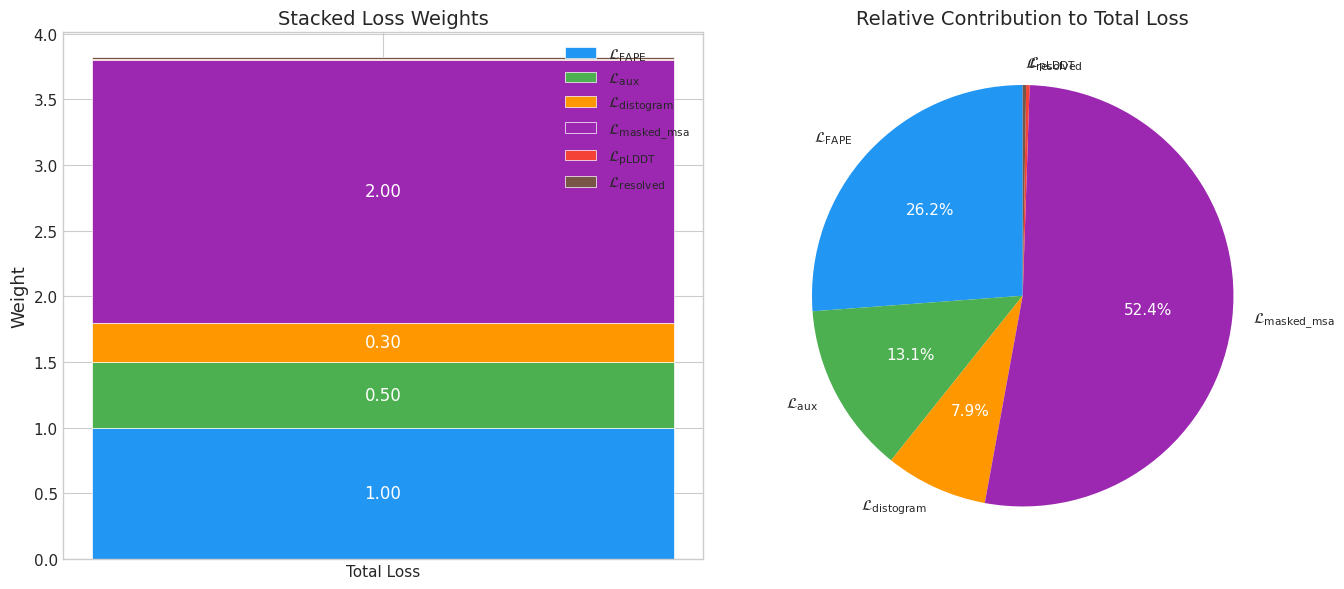

Total weight sum: 3.82

Note: The masked MSA loss has the highest weight (2.0),
reflecting the importance of the self-supervised pretext task.
FAPE (1.0) and auxiliary FAPE (0.5) together dominate the structural supervision.


In [2]:
# Visualize relative weights of each loss component

loss_names = [
    r'$\mathcal{L}_{\mathrm{FAPE}}$',
    r'$\mathcal{L}_{\mathrm{aux}}$',
    r'$\mathcal{L}_{\mathrm{distogram}}$',
    r'$\mathcal{L}_{\mathrm{masked\_msa}}$',
    r'$\mathcal{L}_{\mathrm{pLDDT}}$',
    r'$\mathcal{L}_{\mathrm{resolved}}$'
]
weights = [1.0, 0.5, 0.3, 2.0, 0.01, 0.01]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#795548']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: stacked bar showing the weights
ax = axes[0]
bottom = 0
for i, (name, w) in enumerate(zip(loss_names, weights)):
    ax.bar('Total Loss', w, bottom=bottom, color=colors[i], label=name, edgecolor='white', linewidth=0.5)
    if w > 0.05:
        ax.text(0, bottom + w/2, f'{w:.2f}', ha='center', va='center', fontsize=12, color='white')
    bottom += w
ax.set_ylabel('Weight', fontsize=13)
ax.set_title('Stacked Loss Weights', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, bottom * 1.05)
ax.tick_params(labelsize=11)

# Right: pie chart showing relative contribution
ax2 = axes[1]
total = sum(weights)
fracs = [w / total for w in weights]
wedges, texts, autotexts = ax2.pie(
    fracs, labels=loss_names, autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=colors, startangle=90, textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('white')
ax2.set_title('Relative Contribution to Total Loss', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Total weight sum: {sum(weights):.2f}")
print(f"\nNote: The masked MSA loss has the highest weight ({weights[3]:.1f}),")
print("reflecting the importance of the self-supervised pretext task.")
print("FAPE (1.0) and auxiliary FAPE (0.5) together dominate the structural supervision.")

---
## 2. FAPE: Frame Aligned Point Error

FAPE is the most important innovation in AlphaFold2's training procedure. It provides a **local-frame** structural comparison that is:

1. **Differentiable** -- no SVD or alignment step needed
2. **SE(3)-invariant** -- comparing structures in local frames is automatically invariant to global rotations/translations
3. **Locally sensitive** -- rewards correct local geometry even if global placement is off

### Key Idea

Each residue $i$ defines a **local coordinate frame** $T_i = (R_i, \mathbf{t}_i) \in SE(3)$ from its backbone atoms (N, C$_\alpha$, C). Rather than comparing atom positions in the global frame, FAPE compares them after transforming into **each** residue's local frame.

### Mathematical Definition

$$\text{FAPE} = \frac{1}{N_{\text{frames}} \cdot N_{\text{atoms}}} \sum_{i=1}^{N_f} \sum_{j=1}^{N_a} \left\| T_i^{-1} \circ \hat{\mathbf{x}}_j - T_i^{\text{true}^{-1}} \circ \mathbf{x}_j^{\text{true}} \right\|_{\text{clamp}}$$

where:
- $T_i^{-1} \circ \hat{\mathbf{x}}_j = R_i^T(\hat{\mathbf{x}}_j - \mathbf{t}_i)$ transforms predicted atom $j$ into predicted frame $i$
- $T_i^{\text{true}^{-1}} \circ \mathbf{x}_j^{\text{true}} = R_i^{\text{true}^T}(\mathbf{x}_j^{\text{true}} - \mathbf{t}_i^{\text{true}})$ transforms true atom $j$ into true frame $i$
- $\|d\|_{\text{clamp}} = \min(d, d_{\text{clamp}})$ with $d_{\text{clamp}} = 10$ Angstroms

### Why Clamping?

The clamping at 10 Angstroms prevents outlier atoms (e.g., flexible loops far from the correct position) from producing enormous gradients that destabilize training. Once an atom is more than 10 Angstroms away in any local frame, additional error does not increase the loss further.

In [3]:
# ============================================================
# FAPE Implementation: Step by Step
# ============================================================

def build_alpha_helix(n_residues, noise_std=0.0):
    """
    Build an idealized alpha helix backbone (Ca atoms).
    Alpha helix: rise = 1.5 A per residue, radius = 2.3 A, 3.6 residues per turn.
    Returns Ca positions (n_residues, 3) and local frames (rotations, translations).
    """
    coords = np.zeros((n_residues, 3))
    for k in range(n_residues):
        angle = 2 * np.pi * k / 3.6  # 3.6 residues per turn
        coords[k, 0] = 2.3 * np.cos(angle)
        coords[k, 1] = 2.3 * np.sin(angle)
        coords[k, 2] = 1.5 * k  # rise along z
    
    if noise_std > 0:
        coords += np.random.randn(*coords.shape) * noise_std
    
    return coords


def compute_local_frames(coords):
    """
    Compute local frames for each residue from Ca coordinates.
    Frame i: origin at Ca_i, z-axis along Ca_{i-1}->Ca_{i+1}, 
    x-axis in the plane of (Ca_{i-1}, Ca_i, Ca_{i+1}).
    Returns rotations (n, 3, 3) and translations (n, 3).
    """
    n = len(coords)
    rotations = np.zeros((n, 3, 3))
    translations = coords.copy()  # frame origins at Ca positions
    
    for i in range(n):
        # Get neighboring residues (handle boundaries)
        prev_idx = max(0, i - 1)
        next_idx = min(n - 1, i + 1)
        
        # z-axis: along chain direction
        z = coords[next_idx] - coords[prev_idx]
        z = z / (np.linalg.norm(z) + 1e-8)
        
        # Arbitrary vector for cross product (not parallel to z)
        v = coords[prev_idx] - coords[i]
        if np.linalg.norm(v) < 1e-8:
            v = np.array([1.0, 0.0, 0.0])
        
        # x-axis: perpendicular to z in the plane
        x = v - np.dot(v, z) * z
        x_norm = np.linalg.norm(x)
        if x_norm < 1e-8:
            # z is parallel to v, pick another vector
            v2 = np.array([0.0, 1.0, 0.0])
            x = v2 - np.dot(v2, z) * z
            x_norm = np.linalg.norm(x)
        x = x / (x_norm + 1e-8)
        
        # y-axis: cross product
        y = np.cross(z, x)
        
        rotations[i] = np.stack([x, y, z], axis=-1)  # columns are basis vectors
    
    return rotations, translations


def transform_to_local(coords, rotation, translation):
    """Transform global coords into a local frame: R^T @ (x - t)"""
    return (coords - translation[np.newaxis, :]) @ rotation  # (n_atoms, 3)


def compute_fape(pred_coords, true_coords, pred_frames, true_frames, d_clamp=10.0):
    """
    Compute FAPE between predicted and true structures.
    
    Args:
        pred_coords: (N_atoms, 3) predicted atom positions
        true_coords: (N_atoms, 3) true atom positions
        pred_frames: tuple (rotations, translations) for predicted frames
        true_frames: tuple (rotations, translations) for true frames
        d_clamp: clamping distance in Angstroms
    
    Returns:
        fape_value: scalar FAPE loss
        per_frame_errors: (N_frames,) average error per frame
    """
    pred_R, pred_t = pred_frames
    true_R, true_t = true_frames
    n_frames = len(pred_R)
    n_atoms = len(pred_coords)
    
    per_frame_errors = np.zeros(n_frames)
    
    for i in range(n_frames):
        # Transform predicted atoms into predicted frame i
        pred_local = transform_to_local(pred_coords, pred_R[i], pred_t[i])
        # Transform true atoms into true frame i
        true_local = transform_to_local(true_coords, true_R[i], true_t[i])
        
        # Compute distances and clamp
        dists = np.linalg.norm(pred_local - true_local, axis=-1)
        clamped = np.minimum(dists, d_clamp)
        per_frame_errors[i] = np.mean(clamped)
    
    fape_value = np.mean(per_frame_errors)
    return fape_value, per_frame_errors


# Build true alpha helix (8 residues)
n_res = 8
true_coords = build_alpha_helix(n_res)
true_R, true_t = compute_local_frames(true_coords)

# Build predicted structure (slightly perturbed)
np.random.seed(7)
pred_coords = true_coords + np.random.randn(n_res, 3) * 0.5  # 0.5 A noise
pred_R, pred_t = compute_local_frames(pred_coords)

# Compute FAPE
fape_val, per_frame = compute_fape(pred_coords, true_coords, (pred_R, pred_t), (true_R, true_t))
print(f"FAPE = {fape_val:.4f} Angstroms")
print(f"Per-frame errors: {np.round(per_frame, 3)}")

FAPE = 0.7802 Angstroms
Per-frame errors: [0.786 0.627 0.859 0.928 0.705 1.143 0.918 0.274]


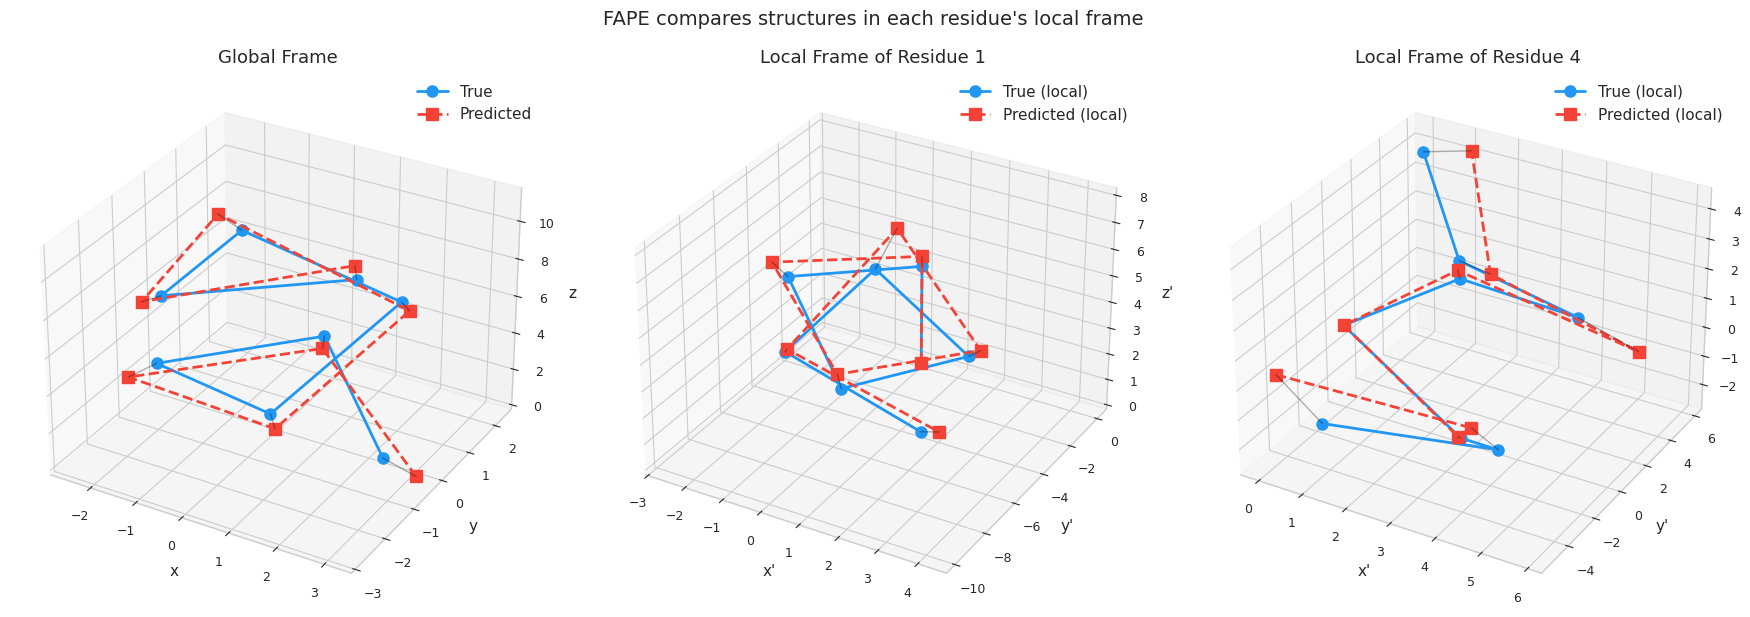

In the global frame (left), we see the overall displacement between true and predicted.
In local frames (center, right), each residue's neighborhood is compared independently.
This captures local accuracy without requiring a global alignment step.


In [4]:
# Visualize FAPE: global frame vs local frames

fig = plt.figure(figsize=(18, 6))

# Panel 1: Global overlay
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(true_coords[:, 0], true_coords[:, 1], true_coords[:, 2],
         'o-', color='#2196F3', markersize=8, linewidth=2, label='True')
ax1.plot(pred_coords[:, 0], pred_coords[:, 1], pred_coords[:, 2],
         's--', color='#F44336', markersize=8, linewidth=2, label='Predicted')
# Draw displacement vectors
for j in range(n_res):
    ax1.plot([true_coords[j, 0], pred_coords[j, 0]],
             [true_coords[j, 1], pred_coords[j, 1]],
             [true_coords[j, 2], pred_coords[j, 2]],
             'k-', alpha=0.3, linewidth=1)
ax1.set_title('Global Frame', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('y', fontsize=11)
ax1.set_zlabel('z', fontsize=11)
ax1.tick_params(labelsize=9)

# Panel 2: Local frame of residue 1
frame_idx = 0
pred_local_1 = transform_to_local(pred_coords, pred_R[frame_idx], pred_t[frame_idx])
true_local_1 = transform_to_local(true_coords, true_R[frame_idx], true_t[frame_idx])

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(true_local_1[:, 0], true_local_1[:, 1], true_local_1[:, 2],
         'o-', color='#2196F3', markersize=8, linewidth=2, label='True (local)')
ax2.plot(pred_local_1[:, 0], pred_local_1[:, 1], pred_local_1[:, 2],
         's--', color='#F44336', markersize=8, linewidth=2, label='Predicted (local)')
for j in range(n_res):
    ax2.plot([true_local_1[j, 0], pred_local_1[j, 0]],
             [true_local_1[j, 1], pred_local_1[j, 1]],
             [true_local_1[j, 2], pred_local_1[j, 2]],
             'k-', alpha=0.3, linewidth=1)
ax2.set_title(f'Local Frame of Residue {frame_idx + 1}', fontsize=13)
ax2.legend(fontsize=11)
ax2.set_xlabel('x\'', fontsize=11)
ax2.set_ylabel('y\'', fontsize=11)
ax2.set_zlabel('z\'', fontsize=11)
ax2.tick_params(labelsize=9)

# Panel 3: Local frame of residue 4
frame_idx = 3
pred_local_4 = transform_to_local(pred_coords, pred_R[frame_idx], pred_t[frame_idx])
true_local_4 = transform_to_local(true_coords, true_R[frame_idx], true_t[frame_idx])

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(true_local_4[:, 0], true_local_4[:, 1], true_local_4[:, 2],
         'o-', color='#2196F3', markersize=8, linewidth=2, label='True (local)')
ax3.plot(pred_local_4[:, 0], pred_local_4[:, 1], pred_local_4[:, 2],
         's--', color='#F44336', markersize=8, linewidth=2, label='Predicted (local)')
for j in range(n_res):
    ax3.plot([true_local_4[j, 0], pred_local_4[j, 0]],
             [true_local_4[j, 1], pred_local_4[j, 1]],
             [true_local_4[j, 2], pred_local_4[j, 2]],
             'k-', alpha=0.3, linewidth=1)
ax3.set_title(f'Local Frame of Residue {frame_idx + 1}', fontsize=13)
ax3.legend(fontsize=11)
ax3.set_xlabel('x\'', fontsize=11)
ax3.set_ylabel('y\'', fontsize=11)
ax3.set_zlabel('z\'', fontsize=11)
ax3.tick_params(labelsize=9)

plt.suptitle('FAPE compares structures in each residue\'s local frame', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("In the global frame (left), we see the overall displacement between true and predicted.")
print("In local frames (center, right), each residue's neighborhood is compared independently.")
print("This captures local accuracy without requiring a global alignment step.")

---
## 3. Why FAPE is Better than RMSD

RMSD (Root Mean Square Deviation) is the traditional metric for comparing protein structures:

$$\text{RMSD} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \|\hat{\mathbf{x}}_i - \mathbf{x}_i\|^2}$$

But RMSD has serious limitations as a **training loss**:

1. **Requires alignment:** The Kabsch algorithm solves $\min_{R,t} \sum_i \|R\hat{\mathbf{x}}_i + t - \mathbf{x}_i\|^2$, which involves an SVD. The gradients through SVD are problematic when singular values are degenerate.

2. **Globally coupled:** A single misplaced domain inflates RMSD for the entire structure, even if other domains are perfect.

3. **Not locally sensitive:** RMSD after global alignment cannot distinguish between "correct fold, wrong placement" and "wrong fold, correct placement."

FAPE addresses all of these issues by comparing atom positions in **every** local frame independently.

In [5]:
# ============================================================
# FAPE vs RMSD: two contrasting scenarios
# ============================================================

def compute_rmsd_no_align(coords1, coords2):
    """RMSD without alignment (just raw coordinate differences)."""
    return np.sqrt(np.mean(np.sum((coords1 - coords2)**2, axis=-1)))


def kabsch_align(mobile, target):
    """Align mobile to target using Kabsch algorithm. Returns aligned mobile."""
    # Center
    mobile_c = mobile - mobile.mean(axis=0)
    target_c = target - target.mean(axis=0)
    # Covariance
    H = mobile_c.T @ target_c
    U, S, Vt = np.linalg.svd(H)
    # Ensure proper rotation (not reflection)
    d = np.linalg.det(Vt.T @ U.T)
    sign_matrix = np.diag([1, 1, np.sign(d)])
    R = Vt.T @ sign_matrix @ U.T
    aligned = mobile_c @ R.T + target.mean(axis=0)
    return aligned


def compute_rmsd_aligned(coords1, coords2):
    """RMSD after Kabsch alignment."""
    aligned = kabsch_align(coords1, coords2)
    return np.sqrt(np.mean(np.sum((aligned - coords2)**2, axis=-1)))


# True structure: alpha helix
n_res = 12
true_struct = build_alpha_helix(n_res)

# Case A: Correct fold, wrong global orientation
# Rotate the entire structure by 60 degrees and translate
theta = np.pi / 3
R_global = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0, 0, 1]
])
case_A = (true_struct @ R_global.T) + np.array([5.0, 3.0, 0.0])
# Add tiny noise so it is not identical
case_A += np.random.randn(*case_A.shape) * 0.15

# Case B: Correct global placement, but local structural errors
case_B = true_struct.copy()
# Add significant local perturbations
np.random.seed(99)
case_B += np.random.randn(*case_B.shape) * 1.5

# Compute metrics
# Unaligned RMSD
rmsd_A_unaligned = compute_rmsd_no_align(case_A, true_struct)
rmsd_B_unaligned = compute_rmsd_no_align(case_B, true_struct)

# Aligned RMSD
rmsd_A_aligned = compute_rmsd_aligned(case_A, true_struct)
rmsd_B_aligned = compute_rmsd_aligned(case_B, true_struct)

# FAPE
frames_true = compute_local_frames(true_struct)
frames_A = compute_local_frames(case_A)
frames_B = compute_local_frames(case_B)

fape_A, _ = compute_fape(case_A, true_struct, frames_A, frames_true)
fape_B, _ = compute_fape(case_B, true_struct, frames_B, frames_true)

print("Scenario A: Correct fold, wrong global orientation (rotated + translated)")
print(f"  RMSD (unaligned) = {rmsd_A_unaligned:.2f} A")
print(f"  RMSD (aligned)   = {rmsd_A_aligned:.2f} A")
print(f"  FAPE             = {fape_A:.2f} A")
print()
print("Scenario B: Correct placement, but local structural errors")
print(f"  RMSD (unaligned) = {rmsd_B_unaligned:.2f} A")
print(f"  RMSD (aligned)   = {rmsd_B_aligned:.2f} A")
print(f"  FAPE             = {fape_B:.2f} A")

Scenario A: Correct fold, wrong global orientation (rotated + translated)
  RMSD (unaligned) = 6.19 A
  RMSD (aligned)   = 0.27 A
  FAPE             = 1.14 A

Scenario B: Correct placement, but local structural errors
  RMSD (unaligned) = 2.23 A
  RMSD (aligned)   = 2.08 A
  FAPE             = 4.59 A


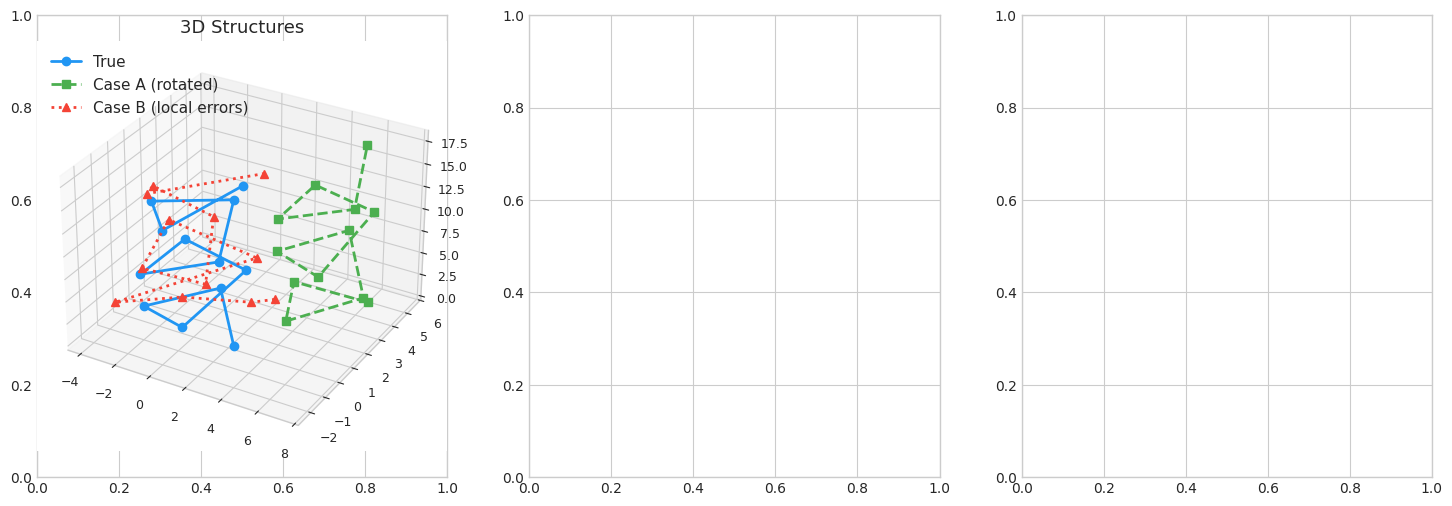

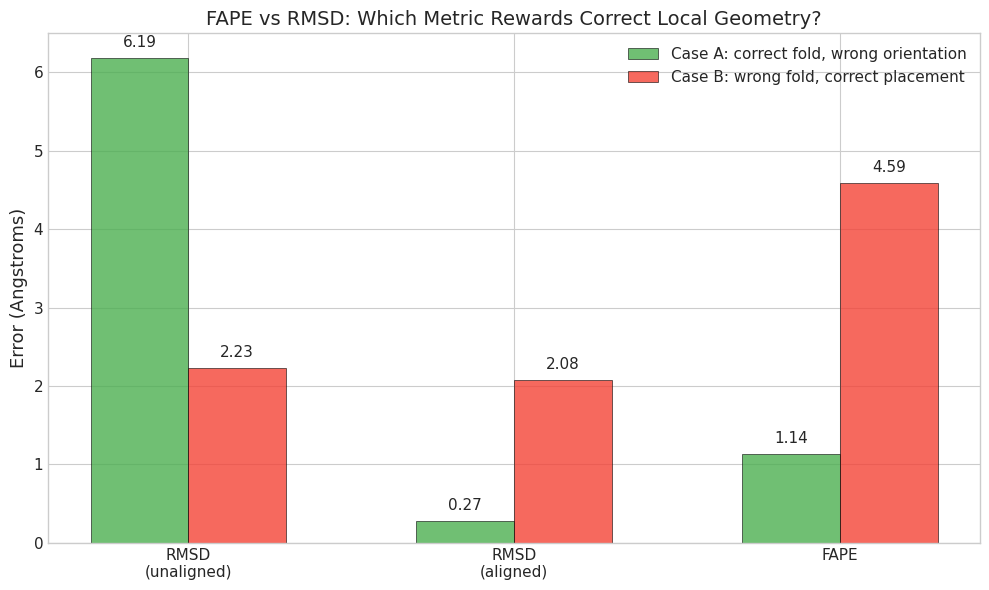


Key insight:
- RMSD (unaligned) severely penalizes Case A due to the global displacement.
- RMSD (aligned) brings Case A close to zero, which is correct.
- FAPE naturally gives Case A a low score (correct local geometry) WITHOUT alignment.
- FAPE gives Case B a high score, correctly reflecting the local structural errors.
- FAPE achieves alignment-free, locally-sensitive structural comparison.


In [6]:
# Visualization: FAPE vs RMSD comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: 3D structures
ax = fig.add_subplot(131, projection='3d')
ax.plot(true_struct[:, 0], true_struct[:, 1], true_struct[:, 2],
        'o-', color='#2196F3', markersize=6, linewidth=2, label='True')
ax.plot(case_A[:, 0], case_A[:, 1], case_A[:, 2],
        's--', color='#4CAF50', markersize=6, linewidth=2, label='Case A (rotated)')
ax.plot(case_B[:, 0], case_B[:, 1], case_B[:, 2],
        '^:', color='#F44336', markersize=6, linewidth=2, label='Case B (local errors)')
ax.set_title('3D Structures', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.tick_params(labelsize=9)

# Panel 2: Bar chart comparison
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.3
metrics_A = [rmsd_A_unaligned, rmsd_A_aligned, fape_A]
metrics_B = [rmsd_B_unaligned, rmsd_B_aligned, fape_B]

bars1 = ax_bar.bar(x - width/2, metrics_A, width, color='#4CAF50', alpha=0.8,
                    label='Case A: correct fold, wrong orientation', edgecolor='black', linewidth=0.5)
bars2 = ax_bar.bar(x + width/2, metrics_B, width, color='#F44336', alpha=0.8,
                    label='Case B: wrong fold, correct placement', edgecolor='black', linewidth=0.5)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(['RMSD\n(unaligned)', 'RMSD\n(aligned)', 'FAPE'], fontsize=12)
ax_bar.set_ylabel('Error (Angstroms)', fontsize=13)
ax_bar.set_title('FAPE vs RMSD: Which Metric Rewards Correct Local Geometry?', fontsize=14)
ax_bar.legend(fontsize=11)
ax_bar.tick_params(labelsize=11)

# Add value labels on bars
for bar_group in [bars1, bars2]:
    for bar in bar_group:
        height = bar.get_height()
        ax_bar.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Close the unused 3D figure subplot axes
plt.close(fig)

print("\nKey insight:")
print("- RMSD (unaligned) severely penalizes Case A due to the global displacement.")
print("- RMSD (aligned) brings Case A close to zero, which is correct.")
print("- FAPE naturally gives Case A a low score (correct local geometry) WITHOUT alignment.")
print("- FAPE gives Case B a high score, correctly reflecting the local structural errors.")
print("- FAPE achieves alignment-free, locally-sensitive structural comparison.")

---
## 4. Auxiliary Losses

The Structure Module runs iteratively (8 iterations in the standard AlphaFold2 configuration), refining the structure at each step. A key training strategy is to apply FAPE loss to the output of **every** iteration, not just the final one:

$$\mathcal{L}_{\text{aux}} = \frac{1}{N_{\text{iter}}} \sum_{l=1}^{N_{\text{iter}}} \text{FAPE}^{(l)}$$

This serves several purposes:

1. **Gradient flow to early layers:** Without auxiliary losses, gradients from the final FAPE must propagate through 8 sequential iterations of the Structure Module. Auxiliary losses provide "shortcut" gradients.

2. **Encouraging convergence at every step:** Each iteration is encouraged to produce a reasonable structure, not just the final one.

3. **Preventing collapse:** Without intermediate supervision, the network might learn to delay all computation to the final iteration, wasting the capacity of earlier iterations.

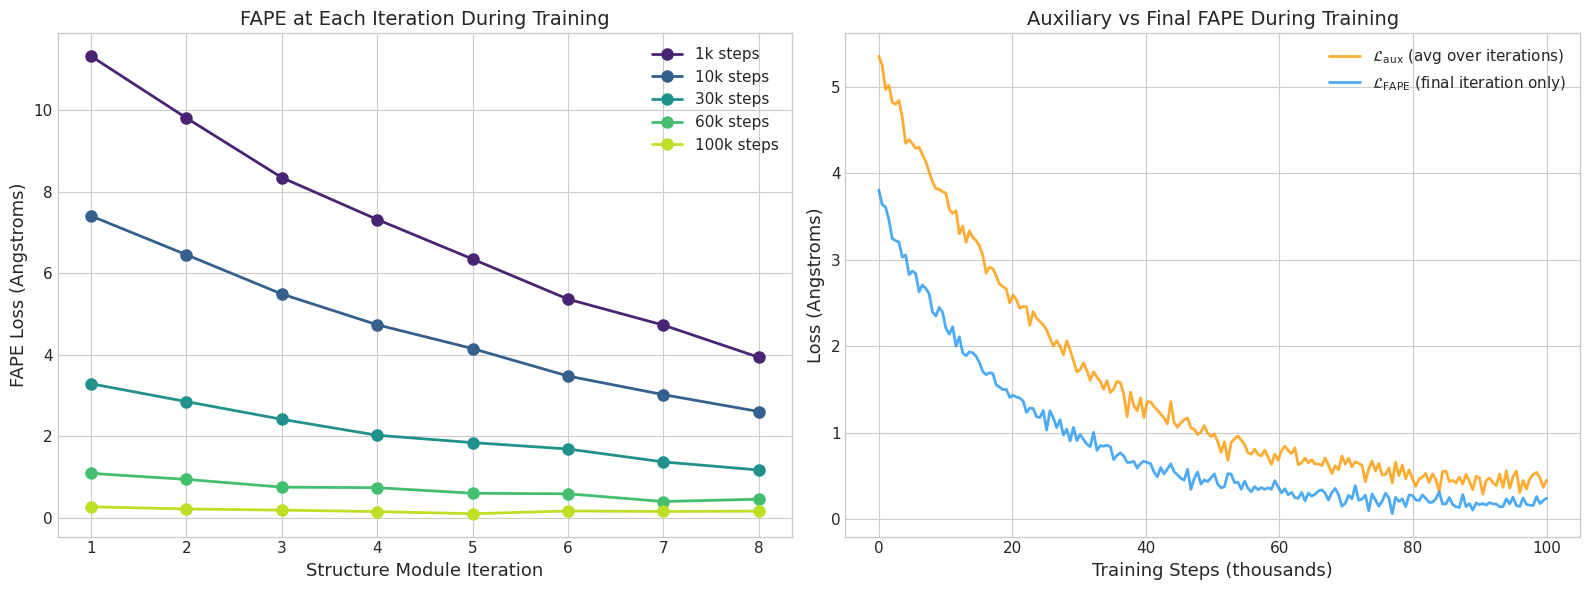

Left: At each training stage, later iterations produce lower FAPE (iterative refinement).
Right: Both auxiliary and final FAPE decrease during training, with final FAPE always lower.
The auxiliary loss ensures gradients flow to all iterations, not just the last.


In [7]:
# ============================================================
# Auxiliary FAPE loss across Structure Module iterations
# ============================================================

# Simulate FAPE loss at each of 8 iterations during training
n_iterations = 8
n_training_snapshots = 5  # show at different points during training

# Early in training: losses are high and don't decrease much across iterations
# Late in training: losses are low and show clear improvement across iterations

training_steps = [1000, 10000, 30000, 60000, 100000]
step_labels = ['1k steps', '10k steps', '30k steps', '60k steps', '100k steps']

iters = np.arange(1, n_iterations + 1)
colors_train = plt.cm.viridis(np.linspace(0.1, 0.9, n_training_snapshots))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: FAPE per iteration at different training stages
for s, (step, label) in enumerate(zip(training_steps, step_labels)):
    # Simulate: base loss decreases with training, slope across iterations also improves
    base = 8.0 * np.exp(-step / 30000)
    decay = np.exp(-0.15 * (iters - 1)) * (1.0 + 0.5 * np.exp(-step / 20000))
    losses = base * decay + np.random.randn(n_iterations) * 0.05
    losses = np.maximum(losses, 0.1)
    ax1.plot(iters, losses, 'o-', color=colors_train[s], markersize=8,
             linewidth=2, label=label)

ax1.set_xlabel('Structure Module Iteration', fontsize=13)
ax1.set_ylabel('FAPE Loss (Angstroms)', fontsize=13)
ax1.set_title('FAPE at Each Iteration During Training', fontsize=14)
ax1.legend(fontsize=11)
ax1.set_xticks(iters)
ax1.tick_params(labelsize=11)

# Right: Average auxiliary loss over training
training_curve_steps = np.linspace(0, 100000, 200)
# Total auxiliary loss (average across iterations)
aux_loss = 5.0 * np.exp(-training_curve_steps / 25000) + 0.3
aux_loss += np.random.randn(len(training_curve_steps)) * 0.08
# Final iteration FAPE only
final_fape = 3.5 * np.exp(-training_curve_steps / 20000) + 0.15
final_fape += np.random.randn(len(training_curve_steps)) * 0.06

ax2.plot(training_curve_steps / 1000, aux_loss, '-', color='#FF9800',
         linewidth=2, alpha=0.8, label=r'$\mathcal{L}_{\mathrm{aux}}$ (avg over iterations)')
ax2.plot(training_curve_steps / 1000, final_fape, '-', color='#2196F3',
         linewidth=2, alpha=0.8, label=r'$\mathcal{L}_{\mathrm{FAPE}}$ (final iteration only)')
ax2.set_xlabel('Training Steps (thousands)', fontsize=13)
ax2.set_ylabel('Loss (Angstroms)', fontsize=13)
ax2.set_title('Auxiliary vs Final FAPE During Training', fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

print("Left: At each training stage, later iterations produce lower FAPE (iterative refinement).")
print("Right: Both auxiliary and final FAPE decrease during training, with final FAPE always lower.")
print("The auxiliary loss ensures gradients flow to all iterations, not just the last.")

---
## 5. Distogram Loss

The distogram head predicts a **distribution** over pairwise C$_\beta$ distances (C$_\alpha$ for glycine), discretized into bins. This provides a complementary structural supervision signal.

### Discretization

Distances are discretized into 64 bins spanning 2.0 to 22.0 Angstroms, with uniform bin width:

$$\Delta = \frac{22.0 - 2.0}{64} = 0.3125 \text{ A}$$

The $b$-th bin covers the interval $[2.0 + (b-1)\Delta, \; 2.0 + b\Delta)$.

### Cross-Entropy Loss

The true distance is converted to a one-hot vector $\mathbf{y}_{ij}$ over bins, and the loss is the cross-entropy between this and the predicted distribution $\hat{\mathbf{p}}_{ij}$:

$$\mathcal{L}_{\text{disto}} = -\sum_{i<j} \sum_{b=1}^{64} y_{ij}^b \log \hat{p}_{ij}^b$$

This loss is applied to the output of the Evoformer's pair representation, encouraging it to encode accurate pairwise geometry.

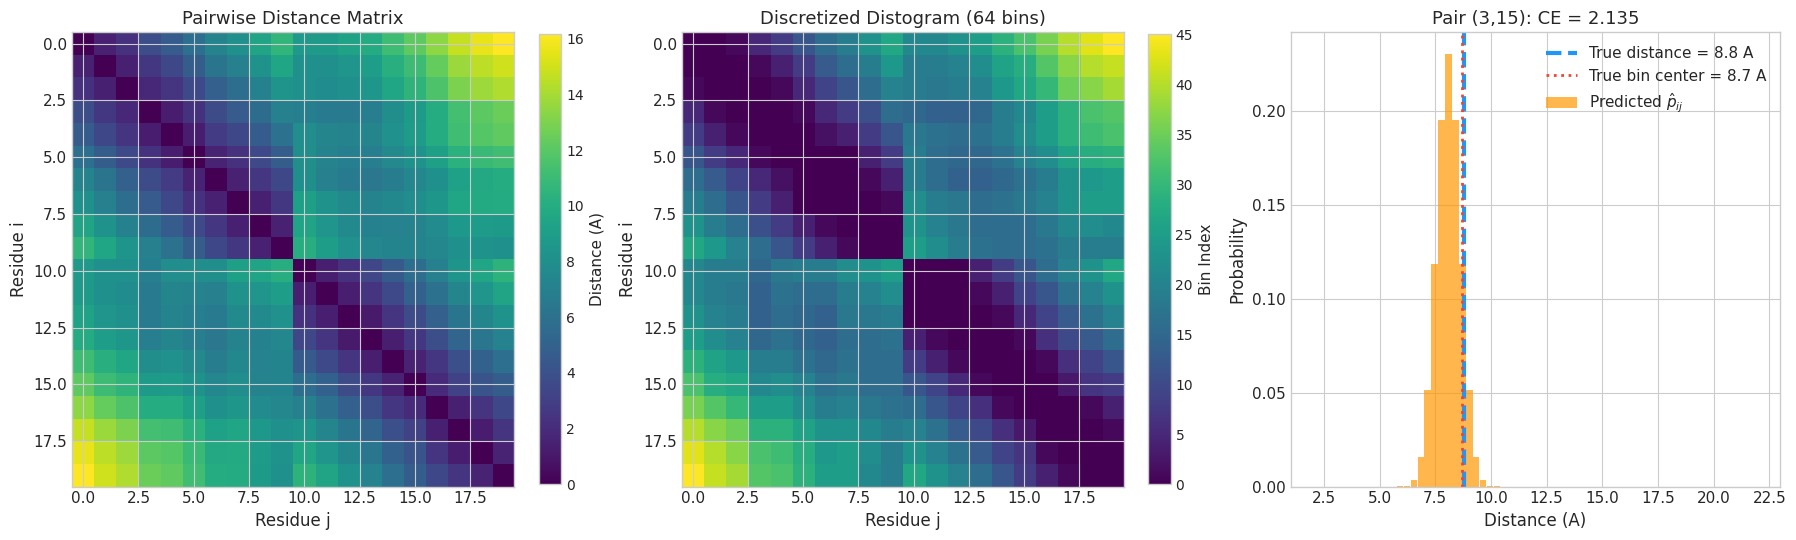

Bin width: 0.3125 A
True distance for pair (3,15): 8.80 A -> bin 21
Cross-entropy for this pair: 2.1349
Note: The predicted distribution is slightly offset from the true bin,
resulting in a non-zero cross-entropy loss that pushes the prediction toward the correct bin.


In [8]:
# ============================================================
# Distogram: distance discretization and cross-entropy loss
# ============================================================

# Create a synthetic distance matrix for a small protein
n_res_disto = 20
np.random.seed(42)
# Build a structure with two "domains" close internally, far apart
coords_disto = np.zeros((n_res_disto, 3))
# Domain 1: residues 0-9
for i in range(10):
    coords_disto[i] = [3.8 * i * 0.3, 3.8 * i * 0.1 + np.random.randn() * 0.5,
                       np.random.randn() * 0.5]
# Domain 2: residues 10-19, offset
for i in range(10, 20):
    coords_disto[i] = [3.8 * (i - 10) * 0.3 + 2.0,
                       3.8 * (i - 10) * 0.1 + 8.0 + np.random.randn() * 0.5,
                       np.random.randn() * 0.5]

# Compute pairwise distance matrix
diff = coords_disto[:, np.newaxis, :] - coords_disto[np.newaxis, :, :]
dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

# Distogram bins
n_bins = 64
bin_min, bin_max = 2.0, 22.0
bin_edges = np.linspace(bin_min, bin_max, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Discretize distances into bins (one-hot)
def distance_to_bin(d, bin_edges):
    """Convert distance to bin index."""
    idx = np.digitize(d, bin_edges) - 1
    idx = np.clip(idx, 0, len(bin_edges) - 2)
    return idx

bin_indices = distance_to_bin(dist_matrix, bin_edges)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: Distance matrix
im1 = axes[0].imshow(dist_matrix, cmap='viridis', aspect='auto')
axes[0].set_title('Pairwise Distance Matrix', fontsize=13)
axes[0].set_xlabel('Residue j', fontsize=12)
axes[0].set_ylabel('Residue i', fontsize=12)
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046)
cbar1.set_label('Distance (A)', fontsize=11)
axes[0].tick_params(labelsize=11)

# Panel 2: Discretized distogram (bin indices)
im2 = axes[1].imshow(bin_indices, cmap='viridis', aspect='auto')
axes[1].set_title('Discretized Distogram (64 bins)', fontsize=13)
axes[1].set_xlabel('Residue j', fontsize=12)
axes[1].set_ylabel('Residue i', fontsize=12)
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046)
cbar2.set_label('Bin Index', fontsize=11)
axes[1].tick_params(labelsize=11)

# Panel 3: Cross-entropy for one residue pair
i_pair, j_pair = 3, 15
true_dist = dist_matrix[i_pair, j_pair]
true_bin = bin_indices[i_pair, j_pair]

# Create a "predicted" probability distribution (softmax-like, peaked near true bin)
logits = -0.5 * (np.arange(n_bins) - true_bin + 2)**2 / 3.0  # slightly off-center
pred_probs = np.exp(logits) / np.sum(np.exp(logits))

# True distribution (one-hot)
true_onehot = np.zeros(n_bins)
true_onehot[true_bin] = 1.0

axes[2].bar(bin_centers, pred_probs, width=bin_width * 0.9, alpha=0.7,
            color='#FF9800', label='Predicted $\hat{p}_{ij}$')
axes[2].axvline(true_dist, color='#2196F3', linewidth=3, linestyle='--',
                label=f'True distance = {true_dist:.1f} A')
axes[2].axvline(bin_centers[true_bin], color='#F44336', linewidth=2, linestyle=':',
                label=f'True bin center = {bin_centers[true_bin]:.1f} A')

# Compute cross-entropy for this pair
ce = -np.sum(true_onehot * np.log(pred_probs + 1e-8))
axes[2].set_title(f'Pair ({i_pair},{j_pair}): CE = {ce:.3f}', fontsize=13)
axes[2].set_xlabel('Distance (A)', fontsize=12)
axes[2].set_ylabel('Probability', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

print(f"Bin width: {bin_width:.4f} A")
print(f"True distance for pair ({i_pair},{j_pair}): {true_dist:.2f} A -> bin {true_bin}")
print(f"Cross-entropy for this pair: {ce:.4f}")
print(f"Note: The predicted distribution is slightly offset from the true bin,")
print(f"resulting in a non-zero cross-entropy loss that pushes the prediction toward the correct bin.")

---
## 6. Masked MSA Loss

Inspired by BERT's masked language modeling, AlphaFold2 employs a **self-supervised** pretext task on the MSA: randomly mask 15% of amino acid positions and train the network to predict the masked identities.

### Mathematical Formulation

Let $M$ denote the set of masked positions $(s, i)$ where $s$ is the sequence index and $i$ is the position index. The loss is:

$$\mathcal{L}_{\text{masked}} = -\frac{1}{|M|}\sum_{(s,i) \in M} \log \hat{p}(a_{si} = a_{si}^{\text{true}})$$

This is simply the average negative log-likelihood of the correct amino acid at each masked position.

### Why This Helps

- Forces the Evoformer to learn **deep evolutionary patterns** in the MSA
- The MSA representation must encode enough information to reconstruct masked residues from context
- Acts as a regularizer, preventing overfitting to structural data
- The masked MSA loss has the **highest weight** ($\lambda_3 = 2.0$) in the total loss, underscoring its importance

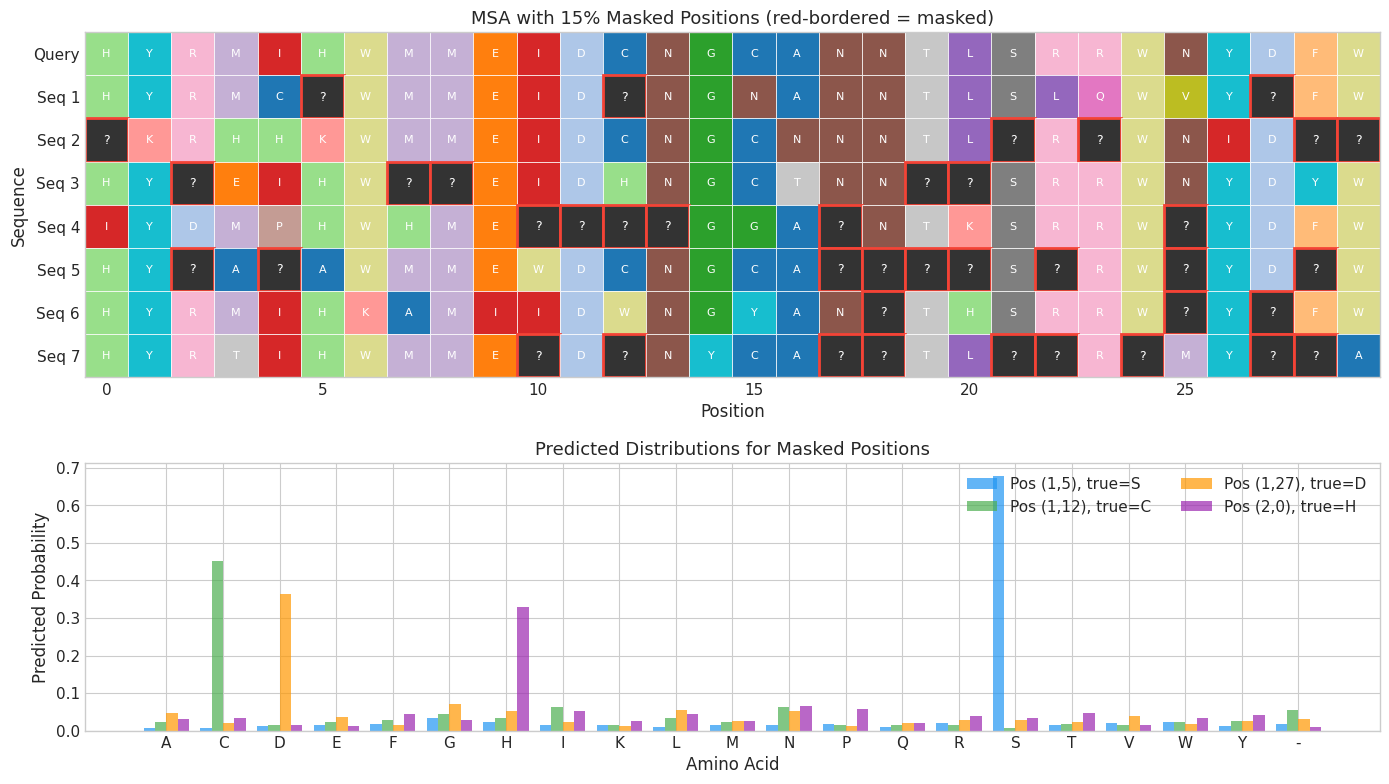


Number of masked positions: 40
Average masked MSA loss: 0.7259
Random baseline would be: 3.0445


In [9]:
# ============================================================
# Masked MSA Loss Visualization
# ============================================================

# Amino acid alphabet (20 standard + gap)
AA_ALPHABET = 'ACDEFGHIKLMNPQRSTVWY-'
n_aa = len(AA_ALPHABET)

# Create a synthetic MSA (8 sequences, 30 positions)
n_seqs, n_pos = 8, 30
np.random.seed(42)

# Start with a "consensus" sequence
consensus = np.random.randint(0, 20, size=n_pos)  # no gaps in consensus

# Generate MSA by mutating from consensus
msa = np.tile(consensus, (n_seqs, 1))
for s in range(1, n_seqs):  # first row is query (keep as consensus)
    n_mutations = np.random.randint(3, 8)
    mut_positions = np.random.choice(n_pos, n_mutations, replace=False)
    for p in mut_positions:
        msa[s, p] = np.random.randint(0, n_aa)

# Apply masking (15% of positions, excluding query sequence row 0)
mask_rate = 0.15
mask = np.random.random((n_seqs, n_pos)) < mask_rate
mask[0, :] = False  # don't mask query sequence
masked_positions = list(zip(*np.where(mask)))

# Create masked MSA (replace masked positions with a special token)
msa_masked = msa.copy()
MASK_TOKEN = -1

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1.5, 1]})

# Top: MSA with masked positions highlighted
ax = axes[0]
# Create a colored MSA image
msa_colors = plt.cm.tab20(msa / n_aa)

# Draw MSA as a grid of colored squares
for s in range(n_seqs):
    for i in range(n_pos):
        color = plt.cm.tab20(msa[s, i] / n_aa)
        alpha = 1.0
        edgecolor = 'white'
        linewidth = 0.5
        if mask[s, i]:
            color = (0.2, 0.2, 0.2, 1.0)  # dark for masked
            edgecolor = '#F44336'
            linewidth = 2
        rect = plt.Rectangle((i, n_seqs - 1 - s), 1, 1, facecolor=color,
                             edgecolor=edgecolor, linewidth=linewidth)
        ax.add_patch(rect)
        # Write amino acid letter
        if mask[s, i]:
            ax.text(i + 0.5, n_seqs - 1 - s + 0.5, '?', ha='center', va='center',
                    fontsize=9, color='white')
        else:
            ax.text(i + 0.5, n_seqs - 1 - s + 0.5, AA_ALPHABET[msa[s, i]],
                    ha='center', va='center', fontsize=8, color='white')

ax.set_xlim(0, n_pos)
ax.set_ylim(0, n_seqs)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Sequence', fontsize=12)
ax.set_title('MSA with 15% Masked Positions (red-bordered = masked)', fontsize=13)
ax.set_yticks(np.arange(n_seqs) + 0.5)
ax.set_yticklabels([f'Seq {n_seqs - 1 - i}' if i < n_seqs - 1 else 'Query'
                     for i in range(n_seqs)], fontsize=11)
ax.set_xticks(np.arange(0, n_pos, 5) + 0.5)
ax.set_xticklabels(np.arange(0, n_pos, 5), fontsize=11)
ax.set_aspect('equal')

# Bottom: predicted probability distributions for a few masked positions
ax2 = axes[1]
n_show = min(4, len(masked_positions))
show_positions = masked_positions[:n_show]

bar_width = 0.8 / n_show
x_aa = np.arange(n_aa)
colors_pred = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for k, (s, i) in enumerate(show_positions):
    true_aa_idx = msa[s, i]
    # Simulate a predicted distribution (peaked at true with some noise)
    logits_pred = np.random.randn(n_aa) * 0.5
    logits_pred[true_aa_idx] += 3.0  # boost true amino acid
    probs_pred = np.exp(logits_pred) / np.sum(np.exp(logits_pred))
    
    offset = (k - n_show / 2 + 0.5) * bar_width
    bars = ax2.bar(x_aa + offset, probs_pred, width=bar_width, alpha=0.7,
                   color=colors_pred[k],
                   label=f'Pos ({s},{i}), true={AA_ALPHABET[true_aa_idx]}')

ax2.set_xticks(x_aa)
ax2.set_xticklabels(list(AA_ALPHABET), fontsize=11)
ax2.set_xlabel('Amino Acid', fontsize=12)
ax2.set_ylabel('Predicted Probability', fontsize=12)
ax2.set_title('Predicted Distributions for Masked Positions', fontsize=13)
ax2.legend(fontsize=11, loc='upper right', ncol=2)
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

# Compute masked MSA loss for the shown positions
total_loss_masked = 0
for s, i in masked_positions:
    true_aa_idx = msa[s, i]
    logits_pred = np.random.randn(n_aa) * 0.5
    logits_pred[true_aa_idx] += 3.0
    probs_pred = np.exp(logits_pred) / np.sum(np.exp(logits_pred))
    total_loss_masked += -np.log(probs_pred[true_aa_idx] + 1e-8)

avg_loss_masked = total_loss_masked / len(masked_positions)
print(f"\nNumber of masked positions: {len(masked_positions)}")
print(f"Average masked MSA loss: {avg_loss_masked:.4f}")
print(f"Random baseline would be: {-np.log(1/n_aa):.4f}")

---
## 7. pLDDT Loss and Confidence Prediction

One of AlphaFold2's most useful outputs is its **confidence estimate**: the predicted Local Distance Difference Test (pLDDT). This tells us how reliable each residue's prediction is.

### lDDT: Local Distance Difference Test

The lDDT score for residue $i$ measures what fraction of pairwise distances involving atom $i$ are predicted within tolerance thresholds:

$$\text{lDDT}_i = \frac{1}{4|S_i|} \sum_{j \in S_i} \sum_{t \in \{0.5, 1, 2, 4\}} \mathbb{1}\left[|d_{ij}^{\text{pred}} - d_{ij}^{\text{true}}| < t\right]$$

where:
- $S_i = \{j : d_{ij}^{\text{true}} < 15 \text{ A}\}$ is the set of atoms within 15 A of atom $i$ in the true structure
- $d_{ij}$ are pairwise C$_\alpha$ distances
- The four tolerance thresholds (0.5, 1, 2, 4 A) capture different levels of accuracy
- lDDT ranges from 0 to 1 (often reported as 0 to 100)

### pLDDT as a Classification Task

AlphaFold2 predicts pLDDT as a **classification** problem: the lDDT range [0, 1] is discretized into 50 bins, and the network predicts a probability distribution over bins. The loss is cross-entropy:

$$\mathcal{L}_{\text{pLDDT}} = -\sum_{i=1}^{N} \sum_{b=1}^{50} y_i^b \log \hat{p}_i^b$$

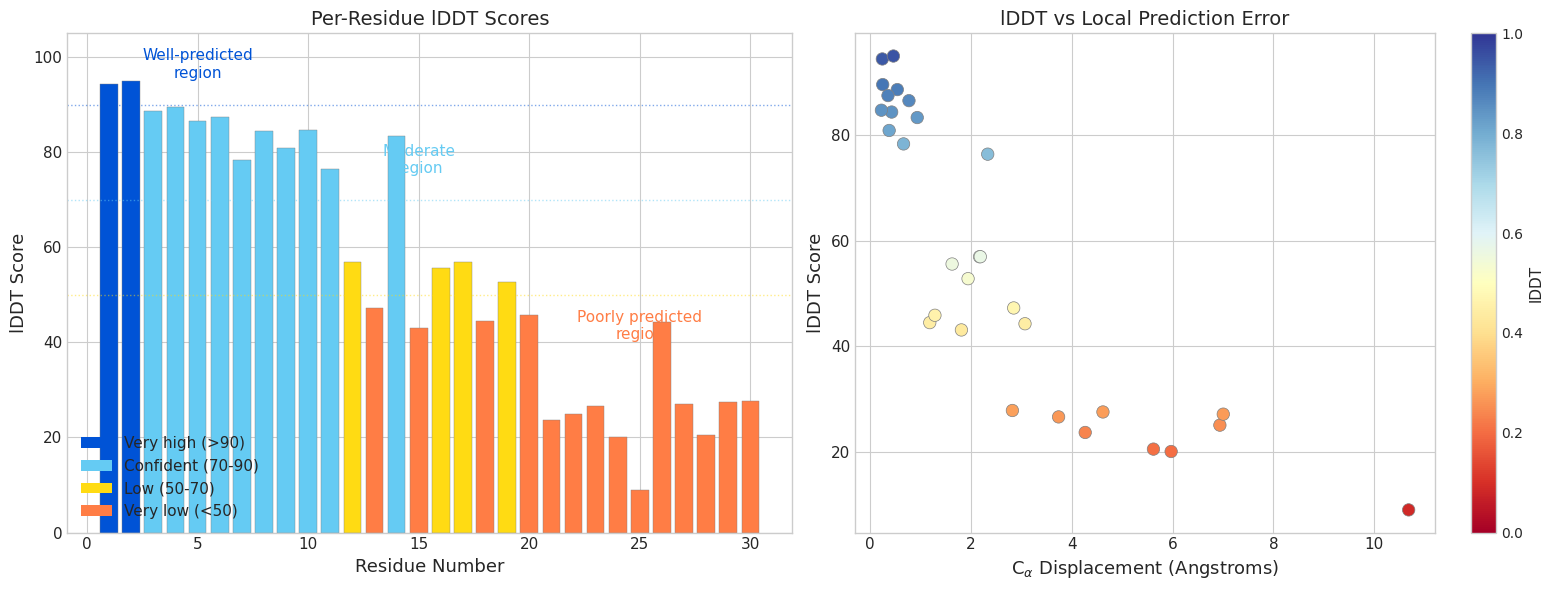

Mean lDDT: 56.1
Residues 1-10 (well-predicted):  mean lDDT = 87.0
Residues 11-20 (moderate):       mean lDDT = 56.2
Residues 21-30 (poor):           mean lDDT = 25.1

lDDT correctly captures the local quality variation across the structure.


In [10]:
# ============================================================
# lDDT computation and pLDDT visualization
# ============================================================

def compute_lddt(pred_coords, true_coords, cutoff=15.0, thresholds=[0.5, 1.0, 2.0, 4.0]):
    """
    Compute per-residue lDDT scores.
    
    Args:
        pred_coords: (N, 3) predicted Ca coordinates
        true_coords: (N, 3) true Ca coordinates  
        cutoff: distance cutoff for inclusion (Angstroms)
        thresholds: tolerance thresholds
    
    Returns:
        lddt_per_residue: (N,) lDDT scores in [0, 1]
    """
    n = len(pred_coords)
    
    # Compute pairwise distances
    pred_dists = np.sqrt(np.sum((pred_coords[:, np.newaxis] - pred_coords[np.newaxis, :])**2, axis=-1))
    true_dists = np.sqrt(np.sum((true_coords[:, np.newaxis] - true_coords[np.newaxis, :])**2, axis=-1))
    
    lddt_per_residue = np.zeros(n)
    
    for i in range(n):
        # Find atoms within cutoff in true structure (excluding self)
        mask_cutoff = (true_dists[i] < cutoff) & (np.arange(n) != i)
        S_i = np.where(mask_cutoff)[0]
        
        if len(S_i) == 0:
            lddt_per_residue[i] = 0.0
            continue
        
        # Compute distance differences
        dist_diff = np.abs(pred_dists[i, S_i] - true_dists[i, S_i])
        
        # Check each threshold
        score = 0.0
        for t in thresholds:
            score += np.mean(dist_diff < t)
        
        lddt_per_residue[i] = score / len(thresholds)
    
    return lddt_per_residue


# Create a synthetic structure pair
n_res_lddt = 30
np.random.seed(42)
true_coords_lddt = build_alpha_helix(n_res_lddt)

# Predicted structure with varying quality
# Good prediction for first 10 residues, moderate for 10-20, poor for 20-30
pred_coords_lddt = true_coords_lddt.copy()
pred_coords_lddt[:10] += np.random.randn(10, 3) * 0.3    # very good
pred_coords_lddt[10:20] += np.random.randn(10, 3) * 1.2  # moderate
pred_coords_lddt[20:] += np.random.randn(10, 3) * 3.5    # poor

# Compute lDDT
lddt_scores = compute_lddt(pred_coords_lddt, true_coords_lddt)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-residue lDDT as colored bar chart
ax = axes[0]
residue_ids = np.arange(1, n_res_lddt + 1)

# Color by lDDT value (AlphaFold coloring scheme)
def lddt_color(score):
    if score >= 0.9:
        return '#0053D6'  # very high confidence (blue)
    elif score >= 0.7:
        return '#65CBF3'  # confident (light blue)
    elif score >= 0.5:
        return '#FFDB13'  # low confidence (yellow)
    else:
        return '#FF7D45'  # very low confidence (orange)

bar_colors = [lddt_color(s) for s in lddt_scores]
bars = ax.bar(residue_ids, lddt_scores * 100, color=bar_colors, edgecolor='gray', linewidth=0.3)

# Add horizontal lines for thresholds
ax.axhline(y=90, color='#0053D6', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(y=70, color='#65CBF3', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(y=50, color='#FFDB13', linestyle=':', alpha=0.5, linewidth=1)

ax.set_xlabel('Residue Number', fontsize=13)
ax.set_ylabel('lDDT Score', fontsize=13)
ax.set_title('Per-Residue lDDT Scores', fontsize=14)
ax.set_ylim(0, 105)
ax.tick_params(labelsize=11)

# Custom legend
legend_elements = [
    mpatches.Patch(facecolor='#0053D6', label='Very high (>90)'),
    mpatches.Patch(facecolor='#65CBF3', label='Confident (70-90)'),
    mpatches.Patch(facecolor='#FFDB13', label='Low (50-70)'),
    mpatches.Patch(facecolor='#FF7D45', label='Very low (<50)')
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower left')

# Annotate regions
ax.annotate('Well-predicted\nregion', xy=(5, 95), fontsize=11, ha='center', va='bottom',
            color='#0053D6')
ax.annotate('Moderate\nregion', xy=(15, 75), fontsize=11, ha='center', va='bottom',
            color='#65CBF3')
ax.annotate('Poorly predicted\nregion', xy=(25, 40), fontsize=11, ha='center', va='bottom',
            color='#FF7D45')

# Right: relationship between displacement and lDDT
ax2 = axes[1]
displacements = np.linalg.norm(pred_coords_lddt - true_coords_lddt, axis=-1)
scatter = ax2.scatter(displacements, lddt_scores * 100, c=lddt_scores,
                      cmap='RdYlBu', s=80, edgecolors='gray', linewidth=0.5,
                      vmin=0, vmax=1)
ax2.set_xlabel('C$_\\alpha$ Displacement (Angstroms)', fontsize=13)
ax2.set_ylabel('lDDT Score', fontsize=13)
ax2.set_title('lDDT vs Local Prediction Error', fontsize=14)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('lDDT', fontsize=11)
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

print(f"Mean lDDT: {np.mean(lddt_scores) * 100:.1f}")
print(f"Residues 1-10 (well-predicted):  mean lDDT = {np.mean(lddt_scores[:10]) * 100:.1f}")
print(f"Residues 11-20 (moderate):       mean lDDT = {np.mean(lddt_scores[10:20]) * 100:.1f}")
print(f"Residues 21-30 (poor):           mean lDDT = {np.mean(lddt_scores[20:]) * 100:.1f}")
print("\nlDDT correctly captures the local quality variation across the structure.")

---
## 8. Experimentally Resolved Loss

Not all atoms in training structures are experimentally resolved. In X-ray crystallography, disordered regions (e.g., flexible loops, terminal residues) may have missing electron density. AlphaFold2 includes a binary classification loss to predict which atoms are resolved:

$$\mathcal{L}_{\text{resolved}} = -\frac{1}{N_{\text{atoms}}} \sum_{k=1}^{N_{\text{atoms}}} \left[ r_k \log \hat{r}_k + (1 - r_k) \log(1 - \hat{r}_k) \right]$$

where $r_k \in \{0, 1\}$ indicates whether atom $k$ is experimentally resolved, and $\hat{r}_k$ is the predicted probability of being resolved.

This loss helps the network learn:
- Which regions of proteins tend to be disordered
- To not "waste" capacity trying to perfectly predict inherently flexible regions
- To handle missing data gracefully during training

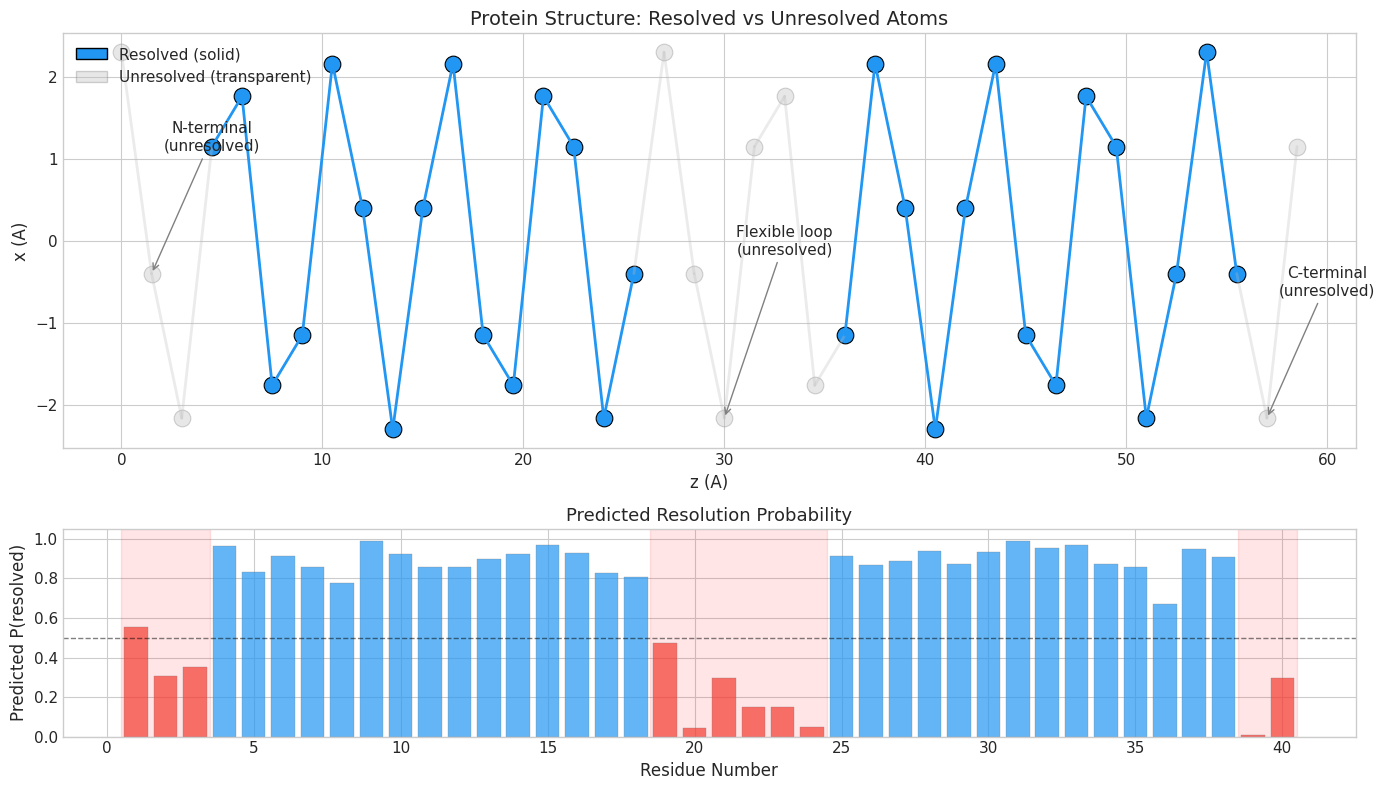

Binary cross-entropy (resolved loss): 0.1679
Resolved atoms: 29/40
Unresolved atoms: 11/40


In [11]:
# ============================================================
# Experimentally Resolved Loss Visualization
# ============================================================

# Create a synthetic structure with resolved and unresolved atoms
n_res_resolved = 40
np.random.seed(42)

# Build a structure
helix_coords = build_alpha_helix(n_res_resolved)

# Mark resolution status:
# - N/C-terminal residues: often unresolved
# - A loop region (residues 18-23): often unresolved
# - Core residues: mostly resolved
resolved = np.ones(n_res_resolved, dtype=bool)
resolved[:3] = False      # N-terminal
resolved[-2:] = False     # C-terminal
resolved[18:24] = False   # flexible loop

# Predicted resolution probabilities
pred_resolved_prob = np.random.beta(5, 1, size=n_res_resolved)  # mostly high
pred_resolved_prob[~resolved] = np.random.beta(1, 3, size=np.sum(~resolved))  # low for unresolved

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

# Top: 3D structure with resolved/unresolved atoms
# Project to 2D for cleaner visualization (side view: x vs z)
ax = ax1
for i in range(n_res_resolved):
    if resolved[i]:
        ax.plot(helix_coords[i, 2], helix_coords[i, 0], 'o', color='#2196F3',
                markersize=12, alpha=1.0, markeredgecolor='black', markeredgewidth=0.8)
    else:
        ax.plot(helix_coords[i, 2], helix_coords[i, 0], 'o', color='#BDBDBD',
                markersize=12, alpha=0.35, markeredgecolor='gray', markeredgewidth=0.8,
                linestyle='none')

# Connect with lines
for i in range(n_res_resolved - 1):
    both_resolved = resolved[i] and resolved[i + 1]
    color = '#2196F3' if both_resolved else '#BDBDBD'
    alpha = 1.0 if both_resolved else 0.3
    ax.plot([helix_coords[i, 2], helix_coords[i + 1, 2]],
            [helix_coords[i, 0], helix_coords[i + 1, 0]],
            '-', color=color, alpha=alpha, linewidth=2)

# Annotations
ax.annotate('N-terminal\n(unresolved)', xy=(helix_coords[1, 2], helix_coords[1, 0]),
            xytext=(helix_coords[1, 2] + 3, helix_coords[1, 0] + 1.5),
            fontsize=11, ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('Flexible loop\n(unresolved)', xy=(helix_coords[20, 2], helix_coords[20, 0]),
            xytext=(helix_coords[20, 2] + 3, helix_coords[20, 0] + 2.0),
            fontsize=11, ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('C-terminal\n(unresolved)', xy=(helix_coords[-2, 2], helix_coords[-2, 0]),
            xytext=(helix_coords[-2, 2] + 3, helix_coords[-2, 0] + 1.5),
            fontsize=11, ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))

resolved_patch = mpatches.Patch(facecolor='#2196F3', edgecolor='black', label='Resolved (solid)')
unresolved_patch = mpatches.Patch(facecolor='#BDBDBD', alpha=0.35, edgecolor='gray',
                                   label='Unresolved (transparent)')
ax.legend(handles=[resolved_patch, unresolved_patch], fontsize=11, loc='upper left')
ax.set_xlabel('z (A)', fontsize=12)
ax.set_ylabel('x (A)', fontsize=12)
ax.set_title('Protein Structure: Resolved vs Unresolved Atoms', fontsize=14)
ax.tick_params(labelsize=11)

# Bottom: predicted resolution probability
residues = np.arange(1, n_res_resolved + 1)
colors_res = ['#2196F3' if r else '#F44336' for r in resolved]
ax2.bar(residues, pred_resolved_prob, color=colors_res, alpha=0.7, edgecolor='gray', linewidth=0.3)
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Residue Number', fontsize=12)
ax2.set_ylabel('Predicted P(resolved)', fontsize=12)
ax2.set_title('Predicted Resolution Probability', fontsize=13)
ax2.set_ylim(0, 1.05)
ax2.tick_params(labelsize=11)

# Shade unresolved regions
for start, end in [(0.5, 3.5), (18.5, 24.5), (38.5, 40.5)]:
    ax2.axvspan(start, end, alpha=0.1, color='red')

plt.tight_layout()
plt.show()

# Compute binary cross-entropy
eps = 1e-8
bce = -np.mean(resolved * np.log(pred_resolved_prob + eps) +
               (1 - resolved) * np.log(1 - pred_resolved_prob + eps))
print(f"Binary cross-entropy (resolved loss): {bce:.4f}")
print(f"Resolved atoms: {np.sum(resolved)}/{n_res_resolved}")
print(f"Unresolved atoms: {np.sum(~resolved)}/{n_res_resolved}")

---
## 9. Self-Distillation and Noisy Student Training

A critical component of AlphaFold2's success was **self-distillation** -- using the model's own high-confidence predictions as additional training data:

1. **Train Model v1** on PDB structures (~170k structures)
2. **Predict** structures for ~350k sequences from UniRef (no experimental structures available)
3. **Filter** predictions by confidence (pLDDT > 70)
4. **Train Model v2** on PDB + filtered predictions

This expanded the effective training set by roughly 2x and was essential for reaching top performance. The approach is related to **noisy student training** from computer vision: the "teacher" model generates labels, and the "student" model trains on them with data augmentation.

Key details:
- Self-distillation labels use less weight than PDB labels
- Only high-confidence predictions are included (pLDDT > 70)
- MSA subsampling adds "noise" during student training
- This is NOT iterative -- only one round of distillation was performed

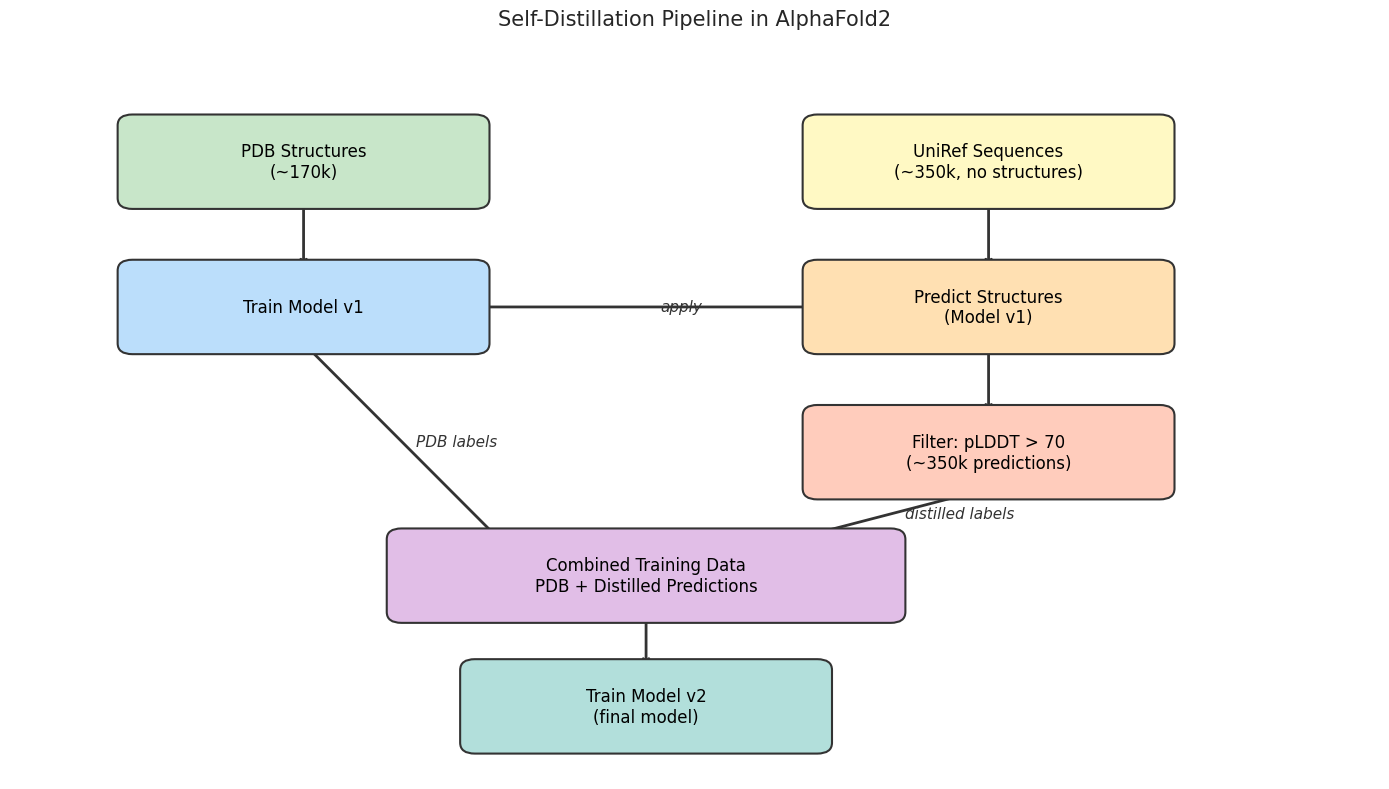

Self-distillation pipeline:
1. Train initial model on PDB experimental structures (~170k)
2. Use Model v1 to predict structures for ~350k UniRef sequences
3. Filter predictions by confidence (pLDDT > 70)
4. Retrain on combined PDB + filtered predictions

This roughly doubled the effective training set and was critical for performance.


In [12]:
# ============================================================
# Self-Distillation Flow Diagram
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# Define box positions and sizes
box_style = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', linewidth=1.5)

def draw_box(ax, x, y, w, h, text, color='#E3F2FD', fontsize=12, text_color='black'):
    """Draw a rounded rectangle with centered text."""
    rect = plt.Rectangle((x - w/2, y - h/2), w, h, linewidth=1.5,
                         edgecolor='#333333', facecolor=color,
                         zorder=2, clip_on=False,
                         joinstyle='round')
    # Round corners
    fancy = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                     boxstyle='round,pad=0.15',
                                     facecolor=color, edgecolor='#333333',
                                     linewidth=1.5, zorder=2)
    ax.add_patch(fancy)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, zorder=3)

def draw_arrow(ax, x1, y1, x2, y2, text='', color='#333333'):
    """Draw an arrow with optional label."""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2),
                zorder=1)
    if text:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx + 0.15, my, text, fontsize=11, ha='left', va='center',
                color=color, style='italic')

# Step 1: PDB Training Data
draw_box(ax, 3, 8.5, 3.5, 1.0, 'PDB Structures\n(~170k)', color='#C8E6C9', fontsize=12)

# Step 2: Train Model v1
draw_box(ax, 3, 6.5, 3.5, 1.0, 'Train Model v1', color='#BBDEFB', fontsize=12)
draw_arrow(ax, 3, 8.0, 3, 7.0)

# Step 3: UniRef sequences
draw_box(ax, 10, 8.5, 3.5, 1.0, 'UniRef Sequences\n(~350k, no structures)', color='#FFF9C4', fontsize=12)

# Step 4: Predict on UniRef
draw_box(ax, 10, 6.5, 3.5, 1.0, 'Predict Structures\n(Model v1)', color='#FFE0B2', fontsize=12)
draw_arrow(ax, 4.75, 6.5, 8.25, 6.5, text='apply')
draw_arrow(ax, 10, 8.0, 10, 7.0)

# Step 5: Filter by confidence
draw_box(ax, 10, 4.5, 3.5, 1.0, 'Filter: pLDDT > 70\n(~350k predictions)', color='#FFCCBC', fontsize=12)
draw_arrow(ax, 10, 6.0, 10, 5.0)

# Step 6: Combined training data
draw_box(ax, 6.5, 2.8, 5.0, 1.0, 'Combined Training Data\nPDB + Distilled Predictions', color='#E1BEE7', fontsize=12)
draw_arrow(ax, 3, 6.0, 5.0, 3.3, text='PDB labels')
draw_arrow(ax, 10, 4.0, 8.0, 3.3, text='distilled labels')

# Step 7: Train Model v2
draw_box(ax, 6.5, 1.0, 3.5, 1.0, 'Train Model v2\n(final model)', color='#B2DFDB', fontsize=12)
draw_arrow(ax, 6.5, 2.3, 6.5, 1.5)

ax.set_title('Self-Distillation Pipeline in AlphaFold2', fontsize=15, pad=20)

plt.tight_layout()
plt.show()

print("Self-distillation pipeline:")
print("1. Train initial model on PDB experimental structures (~170k)")
print("2. Use Model v1 to predict structures for ~350k UniRef sequences")
print("3. Filter predictions by confidence (pLDDT > 70)")
print("4. Retrain on combined PDB + filtered predictions")
print("\nThis roughly doubled the effective training set and was critical for performance.")

---
## 10. Training Regime Summary

AlphaFold2's training proceeded in multiple phases:

### Phase 1: Initial Training
- **Crop size:** 256 residues (random crops from full-length proteins)
- **Batch size:** 128 (across TPU pods)
- **Steps:** ~100k gradient updates
- **Learning rate:** 1e-3 with warm-up and decay
- **Templates:** Disabled initially

### Phase 2: Fine-tuning
- **Crop size:** Increased to 384 residues
- **Templates:** Enabled
- **Learning rate:** Reduced
- **Steps:** Additional ~100k steps

### Phase 3: Self-Distillation
- Train on PDB + high-confidence self-predictions
- Further fine-tuning with distilled data

The total training required approximately 128 TPUv3 cores for about 1 week.

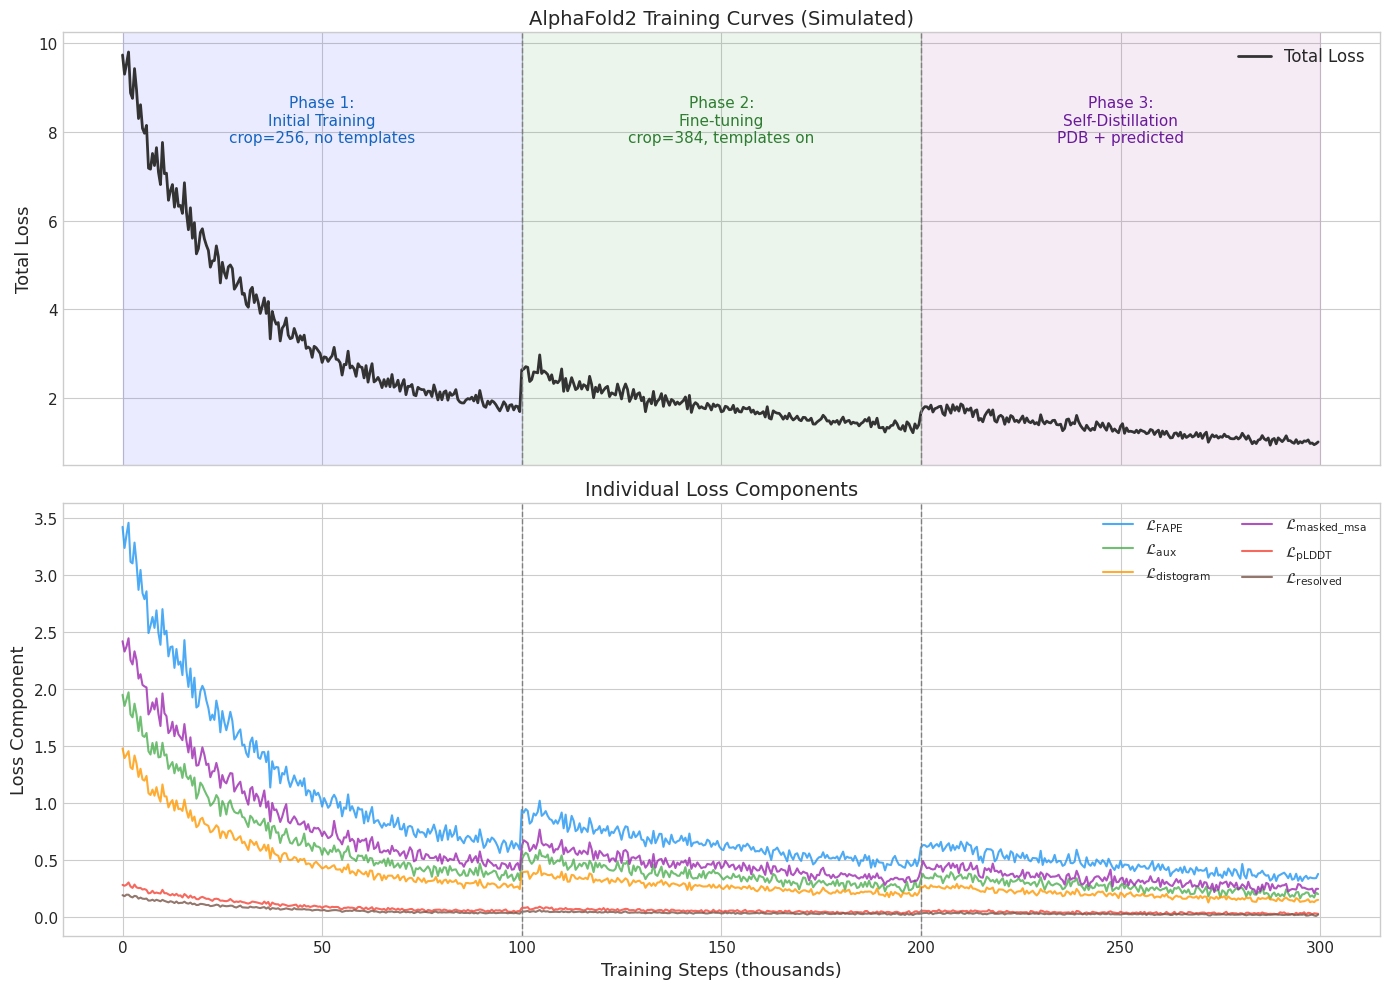

Training regime summary:
  Phase 1 (0-100k steps): Initial training, crop=256, no templates
  Phase 2 (100k-200k steps): Fine-tuning, crop=384, templates enabled
  Phase 3 (200k-300k steps): Self-distillation

Total compute: ~128 TPUv3 cores for ~1 week


In [13]:
# ============================================================
# Training curves with phase annotations
# ============================================================

np.random.seed(42)

# Simulate training steps
total_steps = 300000
steps = np.arange(0, total_steps, 500)

# Phase boundaries
phase1_end = 100000  # initial training
phase2_end = 200000  # fine-tuning
# Phase 3: self-distillation (200k - 300k)

# Simulate total loss
def simulated_loss(steps, phase1_end, phase2_end):
    loss = np.zeros_like(steps, dtype=float)
    for i, s in enumerate(steps):
        if s < phase1_end:
            # Phase 1: rapid decrease
            loss[i] = 8.0 * np.exp(-s / 30000) + 1.5
        elif s < phase2_end:
            # Phase 2: fine-tuning, continued decrease
            base = 8.0 * np.exp(-phase1_end / 30000) + 1.5
            loss[i] = base * np.exp(-(s - phase1_end) / 80000) + 0.8
        else:
            # Phase 3: self-distillation, further improvement
            base2_val = 8.0 * np.exp(-phase1_end / 30000) + 1.5
            base2 = base2_val * np.exp(-(phase2_end - phase1_end) / 80000) + 0.8
            loss[i] = base2 * np.exp(-(s - phase2_end) / 100000) + 0.5
        loss[i] += np.random.randn() * 0.05 * loss[i]  # noise proportional to loss
    return loss

total_loss = simulated_loss(steps, phase1_end, phase2_end)

# Simulate individual loss components
fape_loss = total_loss * 0.35 + np.random.randn(len(steps)) * 0.02
aux_loss = total_loss * 0.20 + np.random.randn(len(steps)) * 0.02
disto_loss = total_loss * 0.15 + np.random.randn(len(steps)) * 0.01
msa_loss = total_loss * 0.25 + np.random.randn(len(steps)) * 0.02
plddt_loss = total_loss * 0.03 + np.random.randn(len(steps)) * 0.005
resolved_loss = total_loss * 0.02 + np.random.randn(len(steps)) * 0.003

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: Total loss
ax1.plot(steps / 1000, total_loss, '-', color='#333333', linewidth=2, label='Total Loss')

# Phase annotations
ax1.axvspan(0, phase1_end / 1000, alpha=0.08, color='blue')
ax1.axvspan(phase1_end / 1000, phase2_end / 1000, alpha=0.08, color='green')
ax1.axvspan(phase2_end / 1000, total_steps / 1000, alpha=0.08, color='purple')

ax1.axvline(phase1_end / 1000, color='gray', linestyle='--', linewidth=1)
ax1.axvline(phase2_end / 1000, color='gray', linestyle='--', linewidth=1)

ax1.text(50, max(total_loss) * 0.9, 'Phase 1:\nInitial Training\ncrop=256, no templates',
         fontsize=11, ha='center', va='top', color='#1565C0')
ax1.text(150, max(total_loss) * 0.9, 'Phase 2:\nFine-tuning\ncrop=384, templates on',
         fontsize=11, ha='center', va='top', color='#2E7D32')
ax1.text(250, max(total_loss) * 0.9, 'Phase 3:\nSelf-Distillation\nPDB + predicted',
         fontsize=11, ha='center', va='top', color='#6A1B9A')

ax1.set_ylabel('Total Loss', fontsize=13)
ax1.set_title('AlphaFold2 Training Curves (Simulated)', fontsize=14)
ax1.legend(fontsize=12, loc='upper right')
ax1.tick_params(labelsize=11)

# Bottom: Individual loss components
ax2.plot(steps / 1000, fape_loss, '-', linewidth=1.5, color='#2196F3',
         label=r'$\mathcal{L}_{\mathrm{FAPE}}$', alpha=0.8)
ax2.plot(steps / 1000, aux_loss, '-', linewidth=1.5, color='#4CAF50',
         label=r'$\mathcal{L}_{\mathrm{aux}}$', alpha=0.8)
ax2.plot(steps / 1000, disto_loss, '-', linewidth=1.5, color='#FF9800',
         label=r'$\mathcal{L}_{\mathrm{distogram}}$', alpha=0.8)
ax2.plot(steps / 1000, msa_loss, '-', linewidth=1.5, color='#9C27B0',
         label=r'$\mathcal{L}_{\mathrm{masked\_msa}}$', alpha=0.8)
ax2.plot(steps / 1000, plddt_loss, '-', linewidth=1.5, color='#F44336',
         label=r'$\mathcal{L}_{\mathrm{pLDDT}}$', alpha=0.8)
ax2.plot(steps / 1000, resolved_loss, '-', linewidth=1.5, color='#795548',
         label=r'$\mathcal{L}_{\mathrm{resolved}}$', alpha=0.8)

ax2.axvline(phase1_end / 1000, color='gray', linestyle='--', linewidth=1)
ax2.axvline(phase2_end / 1000, color='gray', linestyle='--', linewidth=1)

ax2.set_xlabel('Training Steps (thousands)', fontsize=13)
ax2.set_ylabel('Loss Component', fontsize=13)
ax2.set_title('Individual Loss Components', fontsize=14)
ax2.legend(fontsize=11, loc='upper right', ncol=2)
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

print("Training regime summary:")
print(f"  Phase 1 (0-{phase1_end//1000}k steps): Initial training, crop=256, no templates")
print(f"  Phase 2 ({phase1_end//1000}k-{phase2_end//1000}k steps): Fine-tuning, crop=384, templates enabled")
print(f"  Phase 3 ({phase2_end//1000}k-{total_steps//1000}k steps): Self-distillation")
print(f"\nTotal compute: ~128 TPUv3 cores for ~1 week")

---
## 11. Summary and Key Takeaways

### The Multi-Task Loss Landscape

AlphaFold2's total training loss combines six terms, each supervising a different aspect of the prediction:

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{FAPE}}}_{\text{final structure}} + \lambda_1 \underbrace{\mathcal{L}_{\text{aux}}}_{\text{intermediate structures}} + \lambda_2 \underbrace{\mathcal{L}_{\text{distogram}}}_{\text{pairwise distances}} + \lambda_3 \underbrace{\mathcal{L}_{\text{masked\_msa}}}_{\text{sequence recovery}} + \lambda_4 \underbrace{\mathcal{L}_{\text{pLDDT}}}_{\text{confidence}} + \lambda_5 \underbrace{\mathcal{L}_{\text{resolved}}}_{\text{data quality}}$$

### Key Takeaways

1. **FAPE is the key innovation:** By comparing atom positions in local residue frames rather than a global frame, FAPE provides SE(3)-invariant structural supervision that is fully differentiable and locally sensitive -- without requiring the Kabsch alignment.

2. **Clamping prevents gradient explosion:** The clamping at 10 Angstroms ensures that large errors (e.g., in disordered loops) do not dominate the gradient signal.

3. **Auxiliary losses at every iteration** provide gradient shortcuts to early layers of the Structure Module, preventing training collapse.

4. **Distogram loss** supplements structural supervision with pairwise distance distributions, providing a different geometric viewpoint.

5. **Masked MSA loss** acts as both a regularizer and a way to learn deep evolutionary patterns, and carries the highest weight in the total loss.

6. **pLDDT and resolved losses** teach the network to estimate its own confidence and handle missing experimental data.

7. **Self-distillation** roughly doubled the effective training set by using the model's own high-confidence predictions as additional training data.

### Preview: Notebook 8

In the final notebook, we will explore **confidence metrics and result interpretation** -- how to use pLDDT, PAE (Predicted Aligned Error), and other outputs to assess the reliability of AlphaFold2 predictions and interpret them in biological context.

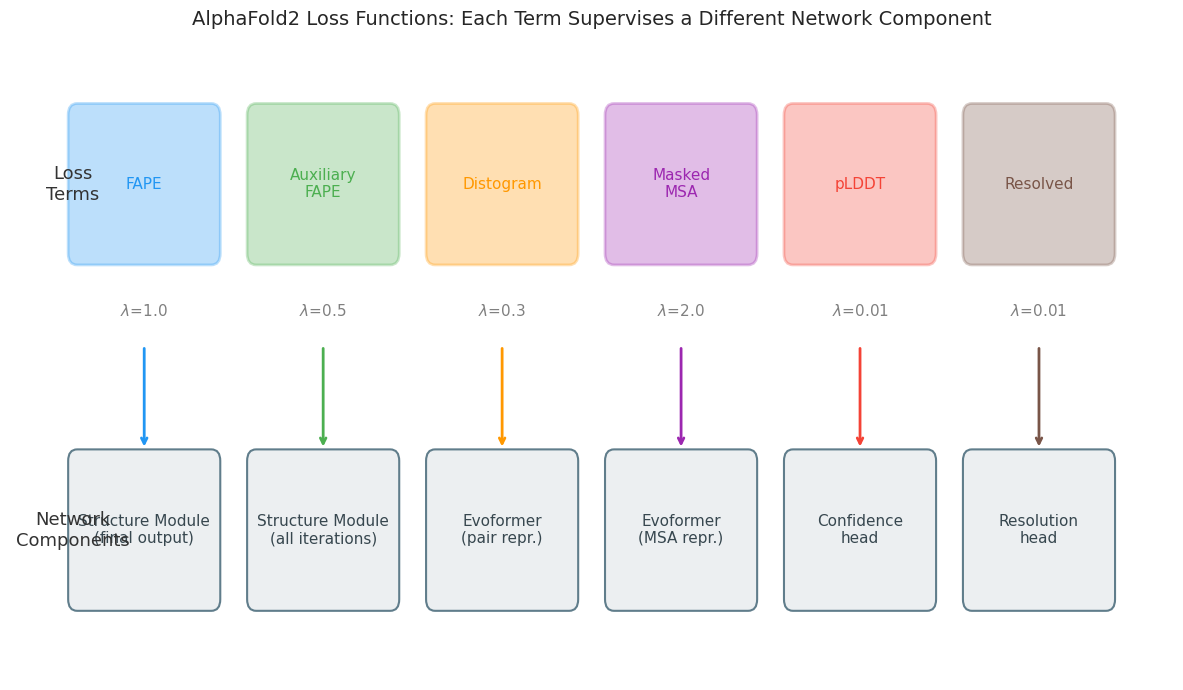

Notebook 7 Complete: Loss Functions and Training in AlphaFold2

Key equations to remember:
  FAPE: local-frame comparison, SE(3)-invariant, clamped at 10 A
  Distogram: cross-entropy over 64 distance bins (2-22 A)
  Masked MSA: BERT-style self-supervised loss on MSA
  pLDDT: per-residue confidence as 50-bin classification

Next: Notebook 8 -- Confidence Metrics and Result Interpretation


In [14]:
# ============================================================
# Final Summary Visualization: the loss landscape
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Create a conceptual diagram showing how each loss guides different parts
components = [
    ('FAPE', 'Structure Module\n(final output)', 1.0, '#2196F3'),
    ('Auxiliary\nFAPE', 'Structure Module\n(all iterations)', 0.5, '#4CAF50'),
    ('Distogram', 'Evoformer\n(pair repr.)', 0.3, '#FF9800'),
    ('Masked\nMSA', 'Evoformer\n(MSA repr.)', 2.0, '#9C27B0'),
    ('pLDDT', 'Confidence\nhead', 0.01, '#F44336'),
    ('Resolved', 'Resolution\nhead', 0.01, '#795548')
]

n_comp = len(components)
x_positions = np.linspace(1, 11, n_comp)

# Draw boxes for loss terms (top) and network components (bottom)
for i, (loss_name, net_part, weight, color) in enumerate(components):
    x = x_positions[i]
    
    # Loss box (top)
    fancy_loss = mpatches.FancyBboxPatch((x - 0.75, 5.2), 1.5, 1.2,
                                          boxstyle='round,pad=0.1',
                                          facecolor=color, alpha=0.3,
                                          edgecolor=color, linewidth=2)
    ax.add_patch(fancy_loss)
    ax.text(x, 5.8, loss_name, ha='center', va='center', fontsize=11, color=color)
    
    # Weight annotation
    ax.text(x, 4.7, f'$\\lambda$={weight}', ha='center', va='center',
            fontsize=11, color='gray')
    
    # Arrow
    ax.annotate('', xy=(x, 3.5), xytext=(x, 4.4),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    
    # Network component box (bottom)
    fancy_net = mpatches.FancyBboxPatch((x - 0.75, 2.2), 1.5, 1.2,
                                         boxstyle='round,pad=0.1',
                                         facecolor='#ECEFF1',
                                         edgecolor='#607D8B', linewidth=1.5)
    ax.add_patch(fancy_net)
    ax.text(x, 2.8, net_part, ha='center', va='center', fontsize=11, color='#37474F')

# Labels
ax.text(0.2, 5.8, 'Loss\nTerms', ha='center', va='center', fontsize=13, color='#333333')
ax.text(0.2, 2.8, 'Network\nComponents', ha='center', va='center', fontsize=13, color='#333333')

ax.set_xlim(-0.5, 12.5)
ax.set_ylim(1.5, 7)
ax.axis('off')
ax.set_title('AlphaFold2 Loss Functions: Each Term Supervises a Different Network Component',
             fontsize=14, pad=15)

plt.tight_layout()
plt.show()

print("="*70)
print("Notebook 7 Complete: Loss Functions and Training in AlphaFold2")
print("="*70)
print("\nKey equations to remember:")
print("  FAPE: local-frame comparison, SE(3)-invariant, clamped at 10 A")
print("  Distogram: cross-entropy over 64 distance bins (2-22 A)")
print("  Masked MSA: BERT-style self-supervised loss on MSA")
print("  pLDDT: per-residue confidence as 50-bin classification")
print("\nNext: Notebook 8 -- Confidence Metrics and Result Interpretation")